In [4]:
import geopandas as gpd
import earthaccess
from peatfire import data_path
import matplotlib.pyplot as plt
import rioxarray
import xarray as xr

In [11]:
peat_restoration = gpd.read_file(
    data_path(
        'processed', 'peat_restoration',
        'NC_Pocosin_Restoration_Sites_2026',
        'NC_Pocosin_Restoration_Sites_2026.shp'
    )
)

nc = gpd.read_file(data_path('processed', 'boundaries', 'nc_boundary.gpkg'))

aoi_nc_peat_80_histosol = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_80_histosol_aoi.gpkg"))

histosol = rioxarray.open_rasterio(data_path("processed", "peat_extent", "conus_histosol_major_percentage_nc.tif"), masked=True)

manually set angola bay's restoration year to 2026 based on what eric soderholm said

In [ ]:
# only need to run this once and it will be saved forever
mask = peat_restoration['Proj_Name'] == 'Angola Bay Restoration Area'
print(peat_restoration.loc[mask, 'End_Yr'])
peat_restoration.loc[mask, 'End_Yr'] = 2026

peat_restoration.to_file(data_path(
        'processed', 'peat_restoration',
        'NC_Pocosin_Restoration_Sites_2026',
        'NC_Pocosin_Restoration_Sites_2026.shp'
    ))

0    2026
Name: End_Yr, dtype: int64


In [12]:
peat_restoration

,Id,acres,Proj_Name,Status_202,Label,Shape__Are,Shape__Len,Start_Yr,End_Yr,geometry
0,0,7496.890384,Angola Bay Restoration Area,Completed,Construction Completed (NCWRC),0.002984,0.296085,2019,2026,"POLYGON Z ((-77.87267 34.67943 0, -77.87263 34..."
1,0,0.000000,GDSNWR Pasquotank Headwaters,Completed,"Hydrologic Restoration Completed (USFWS, DOD, ...",0.004898,0.351833,2019,2023,"POLYGON Z ((-76.47559 36.43284 0, -76.5038 36...."
2,0,0.000000,Hofmann Forest Pocosin Rewetting,Hydrologic Assessment,Hydrologic Assessment & Preliminary Engineerin...,0.006007,0.954599,2022,0,"MULTIPOLYGON Z (((-77.4724 34.87397 0, -77.472..."
3,0,0.000000,PLNWR Flood Resilience,Completed,Community Flood Resilience Enhancement Experim...,0.003330,0.258486,2018,2021,"POLYGON Z ((-76.51245 35.66585 0, -76.5038 35...."
4,0,0.000000,ARNWR Restoration East,Completed,"Hydrologic Restoration Completed (USFWS, DOD, ...",0.004692,0.402038,2009,2019,"POLYGON Z ((-75.73255 35.81382 0, -75.73233 35..."
5,0,0.000000,Clayton Blocks baseline monitoring,Completed,"Carbon Offset Methodology Pilot Site, Clayton ...",0.000106,0.047051,2015,0,"POLYGON Z ((-76.4681 35.62386 0, -76.46934 35...."
6,0,0.000000,Clayton Blocks baseline monitoring,Completed,"Carbon Offset Methodology Pilot Site, Clayton ...",0.000126,0.049915,2015,0,"POLYGON Z ((-76.44681 35.71442 0, -76.44521 35..."
7,0,0.000000,Juniper Creek hydrologic restoration,Proposed,Hydrologic Assessment & Preliminary Engineerin...,0.004543,1.359533,0,0,"MULTIPOLYGON Z (((-78.37313 34.12053 0, -78.37..."
8,0,0.000000,Van Swamp Restoration,Hydrologic Assessment,Hydrologic Assessment & Preliminary Engineerin...,0.001527,0.346599,2022,0,"POLYGON Z ((-76.79121 35.73426 0, -76.78732 35..."
9,0,7597.810000,Great Sandy Run Pocosin,Proposed,Scoping/Feasibility (DOD),0.003023,0.442516,0,0,"MULTIPOLYGON Z (((-77.49432 34.57486 0, -77.49..."


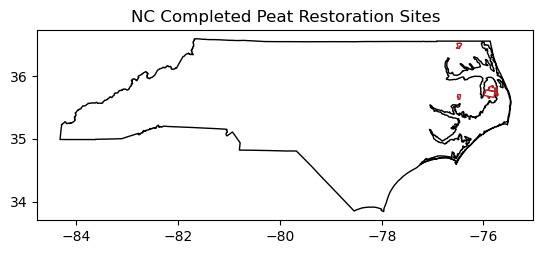

In [3]:
peat_restoration = peat_restoration.to_crs(nc.crs)
completed_peat_restoration = peat_restoration[peat_restoration['End_Yr'] != 0]
aoi_nc_peat_80_histosol = aoi_nc_peat_80_histosol.to_crs(nc.crs)
fig, ax = plt.subplots()

nc.plot(ax=ax, facecolor='none')
completed_peat_restoration.plot(ax=ax, facecolor='none', edgecolor='firebrick', linewidth=1)
ax.set_title('NC Completed Peat Restoration Sites')
fig.savefig('../outputs/figures/peat_restoration/nc_completed_peat_restoration_sites.png')

In [ ]:
aoi_nc_peat_80_histosol_no_restoration = gpd.overlay(aoi_nc_peat_80_histosol, peat_restoration, how='difference')

Text(0.5, 1.0, 'test')

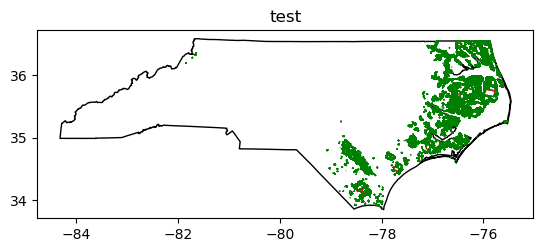

In [ ]:
fig, ax = plt.subplots()

nc.plot(ax=ax, facecolor='none')
peat_restoration.plot(ax=ax, facecolor='none', edgecolor='firebrick', linewidth=1)
aoi_nc_peat_80_histosol_no_restoration.plot(ax=ax, facecolor='none', edgecolor='green', linewidth=1)


In [ ]:
# clip 80% peat mask to drop the peat restoration polygons plus a buffer

# then grab nearest unrestored peat pixels to each restoration site as candidate controls
# then match on distance to coast, elevation, land cover, histosol % using nearest-neighbor via pymatch
# plot before and after matching